In [ ]:
import torch

import torch.nn as nn

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

import tiktoken

import numpy as np

from numpy import ndarray

from pathlib import Path

from tqdm import tqdm

import math

import torch.nn.functional as F

from dataclasses import dataclass

from datasets import load_dataset, DatasetDict, Dataset

# Dataset

I am using the Hugging Face - Tiny Stories dataset like it was mentioned in the task file. The code block below is to download it. Also, just like the repo example, I have used the gpt2 encoder.

In [3]:
# Loading the training and validation datasets

dataset = load_dataset("roneneldan/TinyStories")

print("Downloaded the datasets")

NameError: name 'load_dataset' is not defined

In [4]:
# The encoder using tiktoken

encoder: tiktoken.Encoding = tiktoken.get_encoding("gpt2")

# Printing the tokens to check if it is working

tokens = encoder.encode(dataset["train"][0]["text"])

print(tokens)



NameError: name 'dataset' is not defined

# Task 1 Solution

The model cannot understand words. Hence, we convert them into tokens using something like BPE. After we encode then as token_ids, we have a vocabulary of token_ids. The model then has to embed thee token_ids in to a vector. The dimension of this vector is called the embedding dimension. So during this step we do two types of embedding, positional and token. We then add their result. After this, we have a tensor of shape (B, T, embedding_dim). Here the B and T are due to batches and block_size. Then, we pass it through n layers of the transformer block. After this, we make it go through a layer norm and a linear layer. The self attention is part of the block. After this we get an output tensor, but this has tokens and not words. We decode the tokens and print the generated token. The model essentially guesses the next token.

In [5]:
"""

Just tike the docs ask me to, I am making a function that tokenizes the data. I am using the example used by Karpathy in his nanoGPT repo.

I am using encode_ordinary and adding an end of text token after each line.

"""
def tokenize_text(text_data: dict) -> dict[str, list[int] | int]:

    token_ids = encoder.encode_ordinary(text_data["text"])

    token_ids.append(encoder.eot_token)

    return {"ids" : token_ids, "len" : len(token_ids)}


In [ ]:
# Maping the data to the tokens and storing it in a file

tokenized_data: DatasetDict = dataset.map(tokenize_text, remove_columns = ["text"])

for key, dset in tokenized_data.items():

    array_size: np.uint64 = np.sum(dset["len"], dtype = np.uint64)

    filename = Path.cwd() / f"data/{key}.bin"

    arr = np.memmap(filename, dtype = np.uint16, mode = "w+", shape = (array_size,))

    total_batches: int = 1024

    index: int = 0

    for batch_index in tqdm(range(total_batches), desc = f"Writing to {filename}.bin"):

        batch: Dataset = dset.shard(num_shards = total_batches, index = batch_index, contiguous = True).with_format("numpy")

        array_batch: ndarray = np.concatenate(batch["ids"])

        arr[index : index + len(array_batch)] = array_batch

        index += len(array_batch)

    arr.flush()

In [6]:
# Testing if the files saved the data sucessfully by printing the first 50 tokens.

training_data = np.memmap("data/train.bin", dtype = np.uint16, mode = "r")

validation_data = np.memmap("data/validation.bin", dtype = np.uint16, mode = "r")

print(encoder.decode(training_data[:50].tolist()))

One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.



In [7]:
block_size: int = 128

batch_size: int = 32

vocab_size: int = encoder.n_vocab

device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_batch(split: str) -> tuple[torch.Tensor, torch.Tensor]:

    data = training_data if (split == "train") else validation_data

    ix = torch.randint(len(data) - block_size, (batch_size,))

    x: torch.Tensor = torch.stack([torch.tensor(data[i : i + block_size], dtype = torch.long) for i in ix])

    y: torch.Tensor = torch.stack([torch.tensor(data[i + 1 : i + block_size + 1], dtype = torch.long) for i in ix])

    x = x.to(device)

    y = y.to(device)

    return x, y

In [8]:
# Testing the function by calling it

x, y = get_batch("train")

print(x.shape, y.shape)

torch.Size([32, 128]) torch.Size([32, 128])


# Task 2 Solutions

Tokenisation is the process of converting characters, words or pair of charpacerts and words into tokens but assing them a token_id. The encoder is the object that does that.

We tokenize our data before it goes to the model as the model doesn't truly understand the words or their meanings. The model just does matrix multiplications and additions. But to do that, the input must be numeric, hence we use tokenization.

In [9]:
@dataclass
class GPTConfig():

    vocab_size: int

    block_size: int

    n_layer: int

    n_head: int

    n_embd: int

    dropout: float



In [10]:
# The configuration of the model

gptconfig: GPTConfig = GPTConfig(vocab_size, block_size, 8, 8, 512, 0.1)

In [11]:
class CausalSelfAttention(nn.Module):

    def __init__(self):

        super().__init__()

        self.c_attn = nn.Linear(gptconfig.n_embd, 3 * gptconfig.n_embd)

        assert gptconfig.n_embd % gptconfig.n_head == 0

        self.head_size = gptconfig.n_embd // gptconfig.n_head

        self.proj = nn.Linear(gptconfig.n_embd, gptconfig.n_embd)

        self.dropout = nn.Dropout(gptconfig.dropout)


    def forward(self, x: torch.Tensor) -> torch.Tensor:

        B, T, C = x.shape

        x = self.c_attn(x)

        q, k, v = x.split(C, dim = 2)

        q = q.view(B, T, gptconfig.n_head, self.head_size)

        k = k.view(B, T, gptconfig.n_head, self.head_size)

        v = v.view(B, T, gptconfig.n_head, self.head_size)

        q = q.transpose(1, 2)

        k = k.transpose(1, 2)

        v = v.transpose(1, 2)

        att: torch.Tensor = q @ k.transpose(-2, -1)

        att = att / math.sqrt(self.head_size)

        mask: torch.Tensor = torch.tril(torch.ones(T, T, device = x.device))

        att = att.masked_fill(mask == 0, float("-inf"))

        att = F.softmax(att, dim = -1)

        y: torch.Tensor = att @ v

        y = y.transpose(1, 2)

        y = y.contiguous().view(B, T, C)

        y = self.proj(y)

        return self.dropout(y)    



class Block(nn.Module):

    def __init__(self):

        super().__init__()

        self.ln_1 = nn.LayerNorm(gptconfig.n_embd)

        self.attn = CausalSelfAttention()

        self.ln_2 = nn.LayerNorm(gptconfig.n_embd)

        self.mlp = nn.Sequential(
            nn.Linear(gptconfig.n_embd, 4 * gptconfig.n_embd),
            nn.GELU(),
            nn.Linear(4 * gptconfig.n_embd, gptconfig.n_embd),
            nn.Dropout(gptconfig.dropout)
        )

    
    def forward(self, x: torch.Tensor) -> torch.Tensor:

        x = x + self.attn(self.ln_1(x))

        x = x + self.mlp(self.ln_2(x))

        return x



class GPT(nn.Module):

    def __init__(self):

        super().__init__()

        self.token_embedding = nn.Embedding(gptconfig.vocab_size, gptconfig.n_embd)

        self.position_embedding = nn.Embedding(gptconfig.block_size, gptconfig.n_embd)

        self.blocks = nn.ModuleList([Block() for _ in range(gptconfig.n_layer)])

        self.ln_f = nn.LayerNorm(gptconfig.n_embd)

        self.lm_head = nn.Linear(gptconfig.n_embd, gptconfig.vocab_size)


    def forward(self, x: torch.Tensor) -> torch.Tensor:

        B, T = x.shape

        tok_embd: torch.Tensor = self.token_embedding(x)

        pos: torch.Tensor = torch.arange(T, device = x.device)

        pos_embd: torch.Tensor = self.position_embedding(pos)

        x = tok_embd + pos_embd

        for block in self.blocks:

            x = block(x)

        x = self.ln_f(x)

        return self.lm_head(x)



        

In [13]:
# Hyperparameters

lr: float = 3e-4

# The gptconfig already defined most of them


model: GPT = GPT().to(device)

optimizer: torch.optim.AdamW = torch.optim.AdamW(model.parameters(), lr = lr)

criterion: nn.CrossEntropyLoss = nn.CrossEntropyLoss()

lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max = 40)

In [11]:
# Dummy training step to show that the learning rate is reducing

model.train()

print(f"Original learning rate: {optimizer.param_groups[0]["lr"]}")

optimizer.zero_grad()

x, y = get_batch("train")

output: torch.Tensor = model(x)

B, T, V = output.shape

loss: torch.Tensor = criterion(output.view(B * T, V), y.view(B * T))

loss.backward()

optimizer.step()

lr_scheduler.step()

print(f"Final learning rate: {optimizer.param_groups[0]["lr"]}")

Original learning rate: 0.0003
Final learning rate: 0.00029953760005996916


In [12]:
# The validation function

@torch.no_grad()
def estimate_loss() -> tuple[float, float]:

    model.eval()

    total_val_loss: float = 0.0

    total_training_loss: float = 0.0

    # Getting validation loss

    for _ in range(20):

        x, y = get_batch("validation")

        output: torch.Tensor = model(x)

        B, T, V = output.shape

        loss: torch.Tensor = criterion(output.view(B * T, V), y.view(B * T))

        total_val_loss += loss.item()

    # Getting training loss

    for _ in range(20):

        x, y = get_batch("train")

        output: torch.Tensor = model(x)

        B, T, V = output.shape

        loss: torch.Tensor = criterion(output.view(B * T, V), y.view(B * T))

        total_training_loss += loss.item()

    model.train()

    return total_val_loss / 20, total_training_loss / 20



In [13]:
# Actual training step

model.train()

best_loss: float = float("inf")

# To plot the training and validation loss over steps

steps: list[int] = []

training_losses: list[float] = []

val_losses: list[float] = []

for step in range(10000):

    optimizer.zero_grad()

    x, y = get_batch("train")

    output: torch.Tensor = model(x)

    B, T, V = output.shape

    loss: torch.Tensor = criterion(output.view(B * T, V), y.view(B * T))

    loss.backward()

    optimizer.step()

    lr_scheduler.step()

    if step % 100 == 0:

        val_loss, training_loss = estimate_loss()

        print(f"Step: {step}")

        print(f"Training loss: {training_loss}")

        print(f"Validation loss: {val_loss}")

        steps.append(step)

        training_losses.append(training_loss)

        val_losses.append(val_loss)


        if (val_loss < best_loss):

            best_loss = val_loss

            print("Saving the model.....")

            torch.save({"model":model.state_dict(), "optimizer":optimizer.state_dict(), "step":step}, "gpt_model.pt")

            print(f"Saved the model with the best validation loss of {val_loss}")



Step: 0
Training loss: 9.676009321212769
Validation loss: 9.66899127960205
Saving the model.....
Saved the model with the best validation loss of 9.66899127960205
Step: 100
Training loss: 4.778677821159363
Validation loss: 4.76256914138794
Saving the model.....
Saved the model with the best validation loss of 4.76256914138794
Step: 200
Training loss: 4.262858605384826
Validation loss: 4.299394822120666
Saving the model.....
Saved the model with the best validation loss of 4.299394822120666
Step: 300
Training loss: 3.9975160121917725
Validation loss: 4.02704005241394
Saving the model.....
Saved the model with the best validation loss of 4.02704005241394
Step: 400
Training loss: 3.802432668209076
Validation loss: 3.772435927391052
Saving the model.....
Saved the model with the best validation loss of 3.772435927391052
Step: 500
Training loss: 3.60851674079895
Validation loss: 3.641506481170654
Saving the model.....
Saved the model with the best validation loss of 3.641506481170654
Step: 

KeyboardInterrupt: 

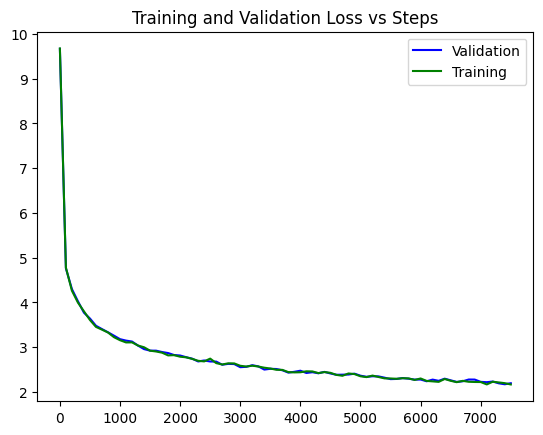

In [14]:
# Plotting the losses

plt.plot(steps, val_losses, label = "Validation", color = "blue")

plt.plot(steps, training_losses, label = "Training", color = "green")

plt.title("Training and Validation Loss vs Steps")

plt.legend()

plt.show()

# Conclusion

The curve shows no trace of under or over fitting. The model has trained perfectly over the iterations. Also GitHub didn't allow me to upload the model and training data files as they exceed the file size limit. Hence you can run those blocks to get them

In [14]:
# Loading the model and setting it in evaluation mode

checkpoint = torch.load("gpt_model.pt", map_location = device)

model.load_state_dict(checkpoint["model"])

model.eval()

print("Model loaded sucessfully")

C:\Users\addy0\AppData\Local\Temp\ipykernel_4864\2024103882.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("gpt_model.pt", map_location = device

Model loaded sucessfully


In [15]:
# Calculating perplexity

val_loss: float = 0.0

with torch.no_grad():

    for _ in range(20):

        x, y = get_batch("validation")

        output: torch.Tensor = model(x)

        B, T, V = output.shape

        loss: torch.Tensor = criterion(output.view(B * T, V), y.view(B * T))

        val_loss += loss.item()

    perplexity: float = math.exp(val_loss / 20)

    print(f"Perplexity is {perplexity}")

Perplexity is 8.950684933069892


In [16]:
# Generating the text based on prompts

prompts: list[str] = ["Hello", "The sun", "Once upon a time", "She was happy"]

num_tokens: int = 25

temperature: float = 0.7

for prompt in prompts:

    prompt_tokens: list[int] = encoder.encode(prompt)

    final_text: str = ""

    x: torch.Tensor = torch.tensor(prompt_tokens, dtype = torch.long, device = device)

    x = x.unsqueeze(0)

    with torch.no_grad():

        for _ in range(num_tokens):

            x_cont = x[:, -gptconfig.block_size:]

            output: torch.Tensor = model(x_cont)

            prob = F.softmax(output[:, -1, :] / temperature, dim = -1)

            next_token = torch.multinomial(prob, num_samples = 1)

            x = torch.cat((x, next_token), dim = 1)

    generated_tokens: list[int] = x[0].tolist()

    final_text: str = encoder.decode(generated_tokens)

    print(f"For the prompt {prompt}")

    print(f"Model: {final_text}")


    


For the prompt Hello
Model: Hello. He saw the lion and the lion. He was surprised and surprised. He roared and chased the lion. He did not
For the prompt The sun
Model: The sun started to shine.

But then, the sun started to shine. The sun shone brightly in the sky. The sky
For the prompt Once upon a time
Model: Once upon a time, there was a little girl named Lily. She loved to play outside and explore the world around her. One day, she
For the prompt She was happy
Model: She was happy to be a good friend. She knew that she could do anything for her.

The moral of the story is that


In [ ]:
# Generating the text based on dynamic prompt

prompt: str = input("Enter text:")

num_tokens: int = int(input("Enter the number of tokens to generate:"))

temperature: float = 0.7

prompt_tokens: list[int] = encoder.encode(prompt)

final_text: str = ""

x: torch.Tensor = torch.tensor(prompt_tokens, dtype = torch.long, device = device)

x = x.unsqueeze(0)

with torch.no_grad():

    for _ in range(num_tokens):

        x_cont = x[:, -gptconfig.block_size:]

        output: torch.Tensor = model(x_cont)

        prob = F.softmax(output[:, -1, :] / temperature, dim = -1)

        next_token = torch.multinomial(prob, num_samples = 1)

        x = torch.cat((x, next_token), dim = 1)

generated_tokens: list[int] = x[0].tolist()

final_text: str = encoder.decode(generated_tokens)

print(f"Model: {final_text}")



Model: The sea in the forest was full of wonderful sights and green, and it even made it so gracefully.<|endoftext|>Once upon a time, there was an orange truck named Jack. He had a big red carousel that he could yield everywhere. Every dayLittle
